# 데이터 탐색

**목적**: Olist 브라질 이커머스 데이터셋의 구조·분포를 파악하고,  
고객 이탈 예측 모델의 방향성을 설정하기 위한 분석

**Time-based Split 기준**
- 피처 추출 구간: 2016-09 ~ 2018-03
- 이탈 레이블 구간: 2018-04 ~ 2018-10 (재주문 없으면 이탈=1)

## 0. 라이브러리 & 설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

plt.style.use('seaborn-v0_8')
sns.set_theme(font_scale=2.5)

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. 데이터 로드 & 날짜 파싱

In [3]:
orders = pd.read_csv('../data/raw/orders.csv')
items = pd.read_csv('../data/raw/order_items.csv')
payments= pd.read_csv('../data/raw/order_payments.csv')
products = pd.read_csv('../data/raw/products.csv')
customers = pd.read_csv('../data/raw/customers.csv')
sellers = pd.read_csv('../data/raw/sellers.csv')
reviews = pd.read_csv('../data/raw/order_reviews.csv')

dt_col = ['order_purchase_timestamp',
          'order_approved_at',
          'order_delivered_carrier_date',
          'order_delivered_customer_date',
          'order_estimated_delivery_date']

for col in dt_col:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

## 2. 데이터셋 체크

In [37]:
def quick_check(data_frame):
    for col in data_frame.columns:
        msg = 'column: {:>30}\t Percent of NAN value: {:.2f}%'.format(col, 100*(data_frame[col].isnull().sum() / data_frame[col].shape[0]))
        print(msg)

    print("\ninfo: ")
    data_frame.info()
    print("\nshape: ", data_frame.shape)
    print("\nduplicates: ", data_frame.duplicated().sum())

    msno.matrix(df=data_frame.iloc[:, :], figsize=(5, 5), color=(0.3, 0.7, 0.5))

column:                     product_id	 Percent of NAN value: 0.00%
column:          product_category_name	 Percent of NAN value: 1.85%
column:            product_name_lenght	 Percent of NAN value: 1.85%
column:     product_description_lenght	 Percent of NAN value: 1.85%
column:             product_photos_qty	 Percent of NAN value: 1.85%
column:               product_weight_g	 Percent of NAN value: 0.01%
column:              product_length_cm	 Percent of NAN value: 0.01%
column:              product_height_cm	 Percent of NAN value: 0.01%
column:               product_width_cm	 Percent of NAN value: 0.01%

info: 
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float6

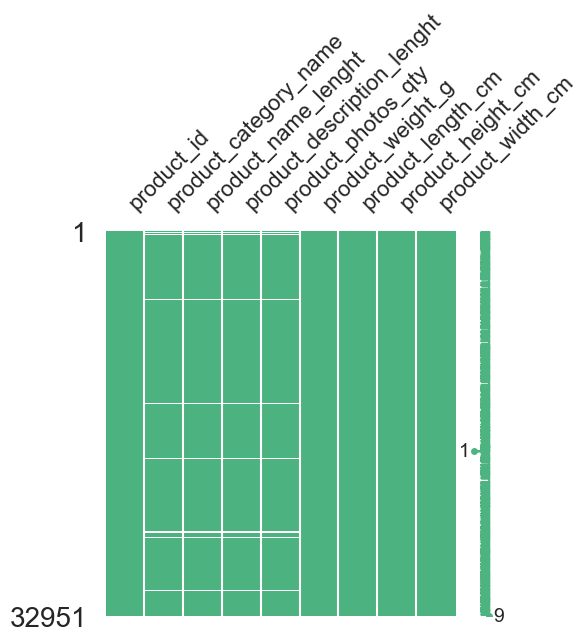

In [38]:
quick_check(products)